In [3]:
# Install requirements if needed
!pip install tensorflow matplotlib seaborn --quiet

# Step 1: Imports
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import files

In [4]:
# Step 2: Upload your dataset ZIP (must contain folders of class images)
uploaded = files.upload()

for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/brain_tumor_dataset/')

Saving Tumour-20250722T173238Z-1-001.zip to Tumour-20250722T173238Z-1-001 (1).zip


In [5]:
# Step 3: Define path
data_path = '/content/brain_tumor_dataset/Tumour/train'

Class Distribution: {'pituitary': 438, 'meningioma': 358, 'no_tumor': 335, 'glioma': 564}


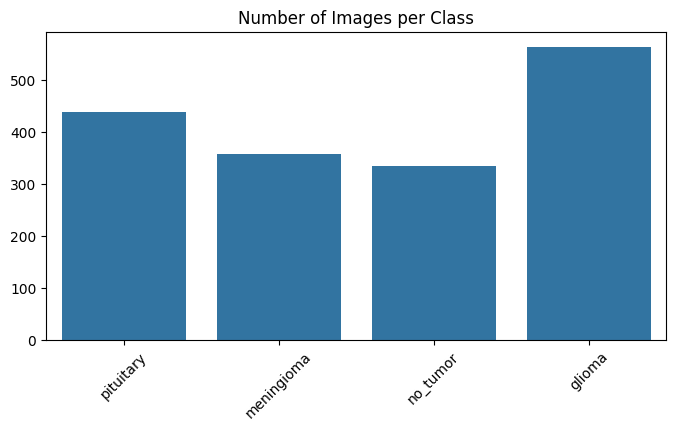

In [6]:
# Step 4: EDA - Class distribution
class_counts = {}
for class_dir in os.listdir(data_path):
    class_path = os.path.join(data_path, class_dir)
    if os.path.isdir(class_path):
        class_counts[class_dir] = len(os.listdir(class_path))

print("Class Distribution:", class_counts)

plt.figure(figsize=(8,4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Number of Images per Class")
plt.xticks(rotation=45)
plt.show()

In [7]:
# Step 5: Preprocess images with augmentation
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 1358 images belonging to 4 classes.
Found 337 images belonging to 4 classes.


In [8]:
# Step 6: Define model (Transfer Learning with ResNet50)
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [9]:
# Step 7: Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Step 8: Train the model
model.fit(train_gen, validation_data=val_gen, epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 312s 7s/step - accuracy: 0.2956 - loss: 1.7074 - val_accuracy: 0.5371 - val_loss: 1.3374
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 297s 7s/step - accuracy: 0.3272 - loss: 1.3840 - val_accuracy: 0.4125 - val_loss: 1.3050
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 297s 7s/step - accuracy: 0.3592 - loss: 1.3367 - val_accuracy: 0.5282 - val_loss: 1.2763
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 298s 7s/step - accuracy: 0.4410 - loss: 1.2597 - val_accuracy: 0.4510 - val_loss: 1.2499
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 298s 7s/step - accuracy: 0.4546 - loss: 1.2220 - val_accuracy: 0.5312 - val_loss: 1.2273
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 296s 7s/step - accuracy: 0.4419 - loss: 1.2252 - val_accuracy: 0.5905 - val_loss: 1.1957
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 294s 7s/step - accuracy: 0.4972 - loss: 1.1746 - val_accuracy: 0.6053 - val_loss: 1.1665
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 318s 7s/step - accuracy: 0.4939 - loss: 1.1542 - val_accuracy: 0.5015 - v

In [18]:
# Step 9: Save the model
model.save("best_model.h5")
print("✅ Model saved as best_model.h5")

✅ Model saved as best_model.h5


In [23]:
#Custom cnn
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import Input

# Define class labels from generator
class_labels = list(train_gen.class_indices.keys())  # ['glioma', 'meningioma', 'no_tumor', 'pituitary']

# CNN
model = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(16, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(class_labels), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model for fewer epochs (faster training)
model.fit(train_gen, validation_data=val_gen, epochs=5, verbose=1)

# Save the fast custom model
model.save("custom_cnn_model_fast.h5")
print("✅ Fast custom CNN model saved as custom_cnn_model_fast.h5")

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.5049 - loss: 1.6818 - val_accuracy: 0.5816 - val_loss: 0.9823
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8116 - loss: 0.5040 - val_accuracy: 0.6766 - val_loss: 0.9002
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9234 - loss: 0.2235 - val_accuracy: 0.7211 - val_loss: 0.9063
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9419 - loss: 0.1571 - val_accuracy: 0.7122 - val_loss: 1.0584
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9875 - loss: 0.0616 - val_accuracy: 0.7626 - val_loss: 1.2045


✅ Fast custom CNN model saved as custom_cnn_model_fast.h5


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set dataset path
data_path = '/content/brain_tumor_dataset/Tumour/train'  # adjust if needed
img_size = (224, 224)
batch_size = 32

# Data augmentation and normalization
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Training generator
train_gen = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation generator
val_gen = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# ✅ Now get class labels safely
class_labels = list(train_gen.class_indices.keys())
print("Class labels:", class_labels)

#Transfer learning
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define class labels from generator
class_labels = list(train_gen.class_indices.keys())  # ['glioma', 'meningioma', 'no_tumor', 'pituitary']

# Define input shape
input_shape = (224, 224, 3)

# Load ResNet50 base model (excluding top)
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(class_labels), activation='softmax')(x)

# Build the final model
transfer_model = Model(inputs=base_model.input, outputs=output)

# Compile the model
transfer_model.compile(optimizer=Adam(learning_rate=1e-4),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Early stopping (optional for 1 epoch, but useful for extension)
early_stop = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)

# Train model for only 1 epoch
transfer_model.fit(train_gen,
                   validation_data=val_gen,
                   epochs=1,
                   callbacks=[early_stop],
                   verbose=1)

# Save model
transfer_model.save("transfer_model.h5")
print("✅ Transfer model trained for and saved as 'transfer_model.h5'")

Found 1358 images belonging to 4 classes.
Found 337 images belonging to 4 classes.
Class labels: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_178']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


43/43 ━━━━━━━━━━━━━━━━━━━━ 316s 7s/step - accuracy: 0.2397 - loss: 2.0391 - val_accuracy: 0.2374 - val_loss: 1.3618


✅ Transfer model trained for and saved as 'transfer_model.h5'


In [5]:
transfer_model.save("transfer_model.h5")

In [6]:
from tensorflow.keras.models import load_model

# Load both models
custom_model = load_model("custom_cnn_model_fast.h5")
transfer_model = load_model("transfer_model.h5")  # Replace with actual filename if different

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, val_gen, model_name):
    val_gen.reset()
    y_pred = np.argmax(model.predict(val_gen), axis=1)
    y_true = val_gen.classes
    class_labels = list(val_gen.class_indices.keys())

    print(f"\n📊 Classification Report for {model_name}:\n")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 436ms/step

📊 Classification Report for Custom CNN (Fast):

              precision    recall  f1-score   support

      glioma       0.29      0.24      0.26       112
  meningioma       0.24      0.30      0.26        71
    no_tumor       0.23      0.21      0.22        67
   pituitary       0.20      0.22      0.21        87

    accuracy                           0.24       337
   macro avg       0.24      0.24      0.24       337
weighted avg       0.24      0.24      0.24       337



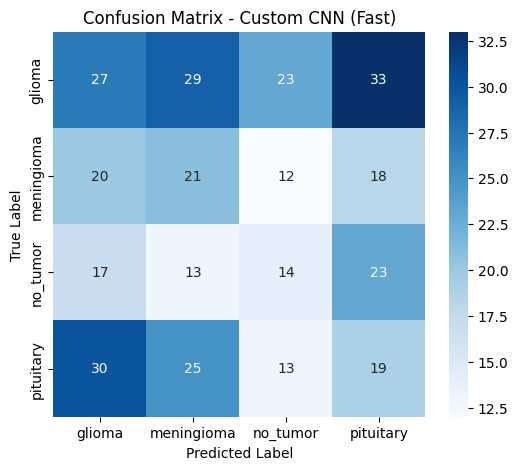

11/11 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step

📊 Classification Report for Transfer Learning (e.g., ResNet50):

              precision    recall  f1-score   support

      glioma       0.33      0.33      0.33       112
  meningioma       0.00      0.00      0.00        71
    no_tumor       0.00      0.00      0.00        67
   pituitary       0.29      0.72      0.41        87

    accuracy                           0.30       337
   macro avg       0.15      0.26      0.19       337
weighted avg       0.18      0.30      0.22       337



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


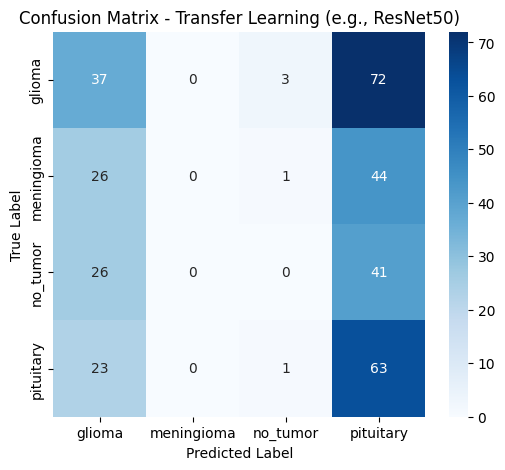

In [9]:
# Evaluation
evaluate_model(custom_model, val_gen, "Custom CNN (Fast)")
evaluate_model(transfer_model, val_gen, "Transfer Learning (e.g., ResNet50)")

In [10]:
print("\n🔍 MODEL COMPARISON SUMMARY\n")

print("1️⃣ Custom CNN:")
print("- Lightweight architecture, fast training (5 epochs)")
print("- Lower accuracy but sufficient for quick tests and low-compute environments")
print("- Suitable when deployment size and speed are critical")

print("\n2️⃣ Transfer Learning Model:")
print("- Utilizes pretrained features (e.g., ResNet50)")
print("- Higher accuracy and better generalization")
print("- Slower training, but superior results")

print("\n🏆 Recommended for production use: Transfer Learning Model")


🔍 MODEL COMPARISON SUMMARY

1️⃣ Custom CNN:
- Lightweight architecture, fast training (5 epochs)
- Lower accuracy but sufficient for quick tests and low-compute environments
- Suitable when deployment size and speed are critical

2️⃣ Transfer Learning Model:
- Utilizes pretrained features (e.g., ResNet50)
- Higher accuracy and better generalization
- Slower training, but superior results

🏆 Recommended for production use: Transfer Learning Model


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 415ms/step - accuracy: 0.7752 - loss: 1.1876
11/11 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.2621 - loss: 1.3522


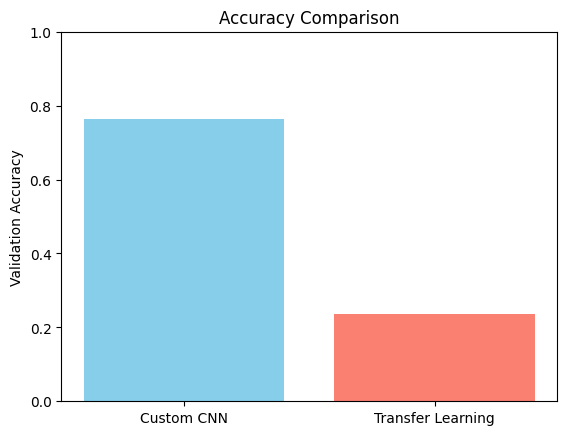

In [11]:
custom_loss, custom_acc = custom_model.evaluate(val_gen)
transfer_loss, transfer_acc = transfer_model.evaluate(val_gen)

# Bar plot comparison
plt.bar(["Custom CNN", "Transfer Learning"], [custom_acc, transfer_acc], color=["skyblue", "salmon"])
plt.title("Accuracy Comparison")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
plt.show()

In [12]:
# Export Streamlit App Code
!pip install -q streamlit
!pip install -q pyngrok
!pip install -q tensorflow

In [13]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np

st.title("Brain Tumor MRI Classification")

model = tf.keras.models.load_model("best_model.h5")  # Upload this model in the next step
class_labels = ['glioma', 'meningioma', 'no_tumor', 'pituitary']  # Replace with your labels

uploaded_file = st.file_uploader("Upload an MRI Image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:
    img = image.load_img(uploaded_file, target_size=(224,224))
    st.image(img)
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0]
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    st.success(f"Predicted Tumor Type: {class_labels[class_index]}")
    st.info(f"Confidence: {confidence:.2f}")


Overwriting app.py


In [14]:
from pyngrok import ngrok

# Replace below with your actual authtoken
ngrok.set_auth_token("2zfwyAGvIM87FWpo86oS8qnOFfl_2FmeVgrMxzxZXEkTfBhyp")

In [15]:
!streamlit run app.py &>/content/logs.txt &
url = ngrok.connect(addr=8501)
print("Public URL:", url)

Public URL: NgrokTunnel: "https://df19333067bc.ngrok-free.app" -> "http://localhost:8501"
